Final Project Draft: [Student Dropout Prediction]
Kennedy Madison
Due: 4/5/26

## 1. Problem Statement & Dataset
How can we predict whether a student will drop out of school and can we prevent it? The data set provides different demographics and categories that can help us identfy possible patterns of a student drop out incident]

In [78]:
## Data Loading & Exploration
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("student_dropout_dataset_v3.csv")  

df.head()
df.info()
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             10000 non-null  int64  
 1   Age                    10000 non-null  float64
 2   Gender                 10000 non-null  str    
 3   Family_Income          9500 non-null   float64
 4   Internet_Access        10000 non-null  str    
 5   Study_Hours_per_Day    9500 non-null   float64
 6   Attendance_Rate        10000 non-null  float64
 7   Assignment_Delay_Days  10000 non-null  int64  
 8   Travel_Time_Minutes    10000 non-null  float64
 9   Part_Time_Job          10000 non-null  str    
 10  Scholarship            10000 non-null  str    
 11  Stress_Index           9500 non-null   float64
 12  GPA                    10000 non-null  float64
 13  Semester_GPA           10000 non-null  float64
 14  CGPA                   10000 non-null  float64
 15  Semester      

,Student_ID,Age,Family_Income,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Stress_Index,GPA,Semester_GPA,CGPA,Dropout
count,10000.00000,10000.00000,9500.000000,9500.000000,10000.00000,10000.000000,10000.00000,9500.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,21.02606,38377.247474,4.014592,81.73683,1.799700,30.17926,5.507147,2.308440,2.300057,2.298761,0.23540
std,2886.89568,2.13981,20496.232179,1.295450,8.22093,1.344307,11.91887,1.765951,1.061717,1.074407,1.072555,0.42427
min,1.00000,17.00000,25000.000000,0.500000,38.20000,0.000000,5.00000,1.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,19.50000,25000.000000,3.160000,76.40000,1.000000,21.90000,4.300000,1.550000,1.520000,1.520000,0.00000
50%,5000.50000,21.00000,29740.500000,4.000000,81.80000,2.000000,30.20000,5.500000,2.350000,2.350000,2.350000,0.00000
75%,7500.25000,22.50000,44520.000000,4.870000,87.30000,3.000000,38.40000,6.700000,3.120000,3.150000,3.150000,0.00000
max,10000.00000,29.60000,316601.000000,8.980000,100.00000,8.000000,74.90000,10.000000,4.000000,4.000000,4.000000,1.00000


In [ ]:
#This is the amount of missing values within each category
df.isnull().sum()


Student_ID                 0
Age                        0
Gender                     0
Family_Income            500
Internet_Access            0
Study_Hours_per_Day      500
Attendance_Rate            0
Assignment_Delay_Days      0
Travel_Time_Minutes        0
Part_Time_Job              0
Scholarship                0
Stress_Index             500
GPA                        0
Semester_GPA               0
CGPA                       0
Semester                   0
Department                 0
Parental_Education       511
Dropout                    0
dtype: int64

In [ ]:
# I had to fill in the missing values in the data set
numeric_cols = df.select_dtypes(include='number').columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])


C:\Users\kgmad\AppData\Local\Temp\ipykernel_11656\4216477938.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns


In [ ]:
#New data set, with no more missing values
df.isnull().sum()

Student_ID               0
Age                      0
Gender                   0
Family_Income            0
Internet_Access          0
Study_Hours_per_Day      0
Attendance_Rate          0
Assignment_Delay_Days    0
Travel_Time_Minutes      0
Part_Time_Job            0
Scholarship              0
Stress_Index             0
GPA                      0
Semester_GPA             0
CGPA                     0
Semester                 0
Department               0
Parental_Education       0
Dropout                  0
dtype: int64

In [8]:
df.head()

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,29740.5,Yes,4.00,82.2,2,38.6,No,No,5.5,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0


In [ ]:
## 3. Feature Engineering
#does income level affect dropout rate?
df['low_income'] = (df['Family_Income'] < df['Family_Income'].median()).astype(int)

In [ ]:
#Does stress level affect dropout rate?
df['high_stress'] = (df['Stress_Index'] >= 7).astype(int)

In [31]:
#academic performance comparison based on semester
df['gpa_gap'] = df['GPA'] - df['Semester_GPA']

In [ ]:
#Scholarship vs no scholarship feature
df['has_scholarship'] = (df['Scholarship'] == 'Yes').astype(int)

In [ ]:
#does the student have a part time job or not?
df['has_part_time_job'] = (df['Part_Time_Job'] == 'Yes').astype(int)


In [60]:
#Had to fill in missing values again after feature engineering
X_train = X_train.fillna(X_train.median(numeric_only=True))
X_test = X_test.fillna(X_train.median(numeric_only=True))

<Figure size 640x480 with 0 Axes>

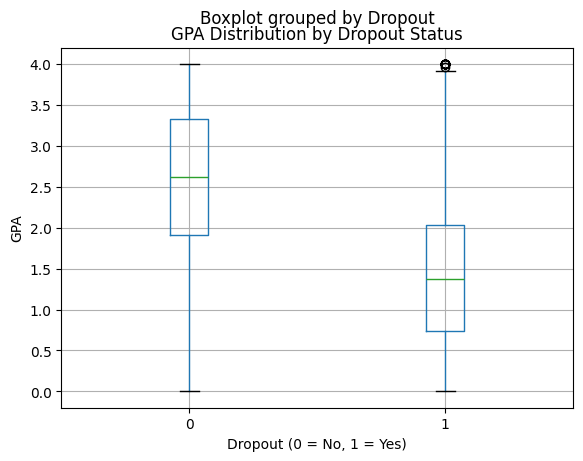

In [ ]:
plt.figure()
df.boxplot(column='GPA', by='Dropout')
plt.title("GPA Distribution vs Dropout Status")
plt.xlabel("Dropout (0 = No, 1 = Yes)")
plt.ylabel("GPA")
plt.show()

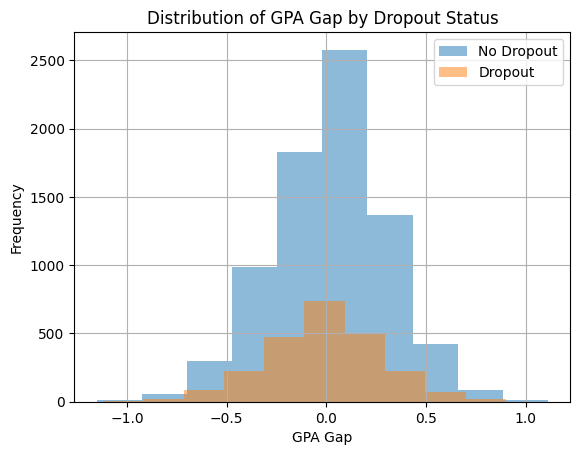

In [44]:
plt.figure()
df[df['Dropout'] == 0]['gpa_gap'].hist(alpha=0.5, label='No Dropout')
df[df['Dropout'] == 1]['gpa_gap'].hist(alpha=0.5, label='Dropout')
plt.title("Distribution of GPA Gap by Dropout Status")
plt.xlabel("GPA Gap")
plt.ylabel("Frequency")
plt.legend()
plt.show()

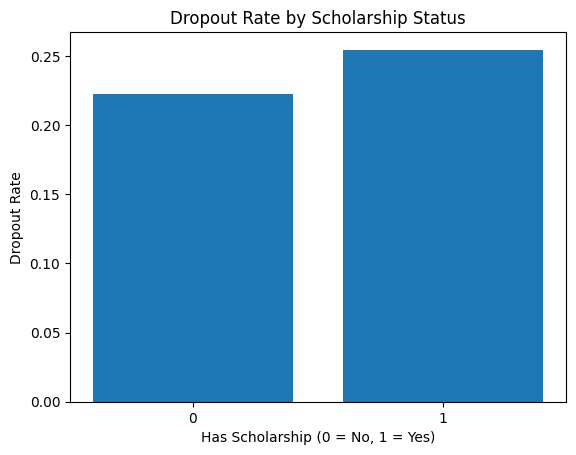

In [ ]:

plt.figure()
plt.bar(dropout_rate.index.astype(str), dropout_rate.values)
plt.title("Dropout Rate by Scholarship Status")
plt.xlabel("Has Scholarship (0 = No, 1 = Yes)")
plt.ylabel("Dropout Rate")
plt.show()

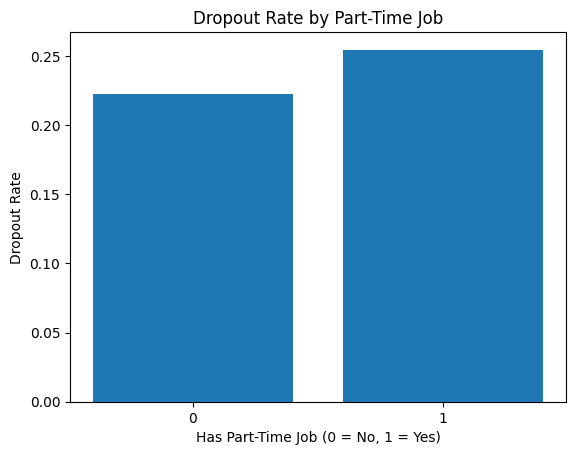

In [47]:


plt.figure()
plt.bar(dropout_rate.index.astype(str), dropout_rate.values)
plt.title("Dropout Rate by Part-Time Job")
plt.xlabel("Has Part-Time Job (0 = No, 1 = Yes)")
plt.ylabel("Dropout Rate")
plt.show()

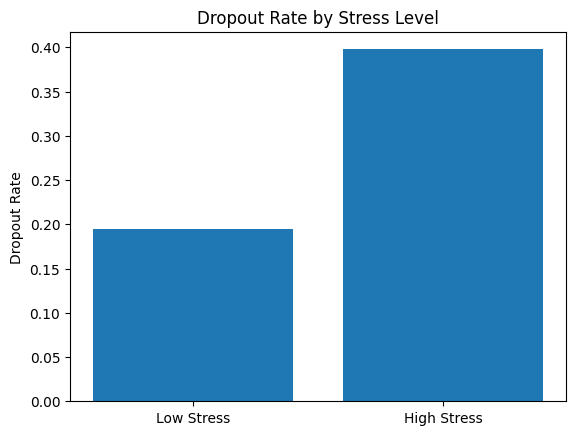

In [ ]:
plt.figure()
plt.bar(['Low Stress', 'High Stress'], stress_rate.values)
plt.title("Dropout Rate by Stress Level")
plt.ylabel("Dropout Rate")
plt.show()

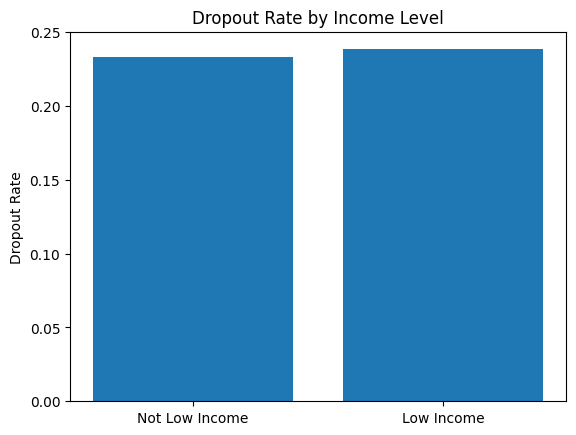

In [ ]:
plt.figure()
plt.bar(['Not Low Income', 'Low Income'], income_rate.values)
plt.title("Dropout Rate by Income Level")
plt.ylabel("Dropout Rate")
plt.show()

In [49]:
##4 Data processing
from sklearn.model_selection import train_test_split

X = df[[
    'GPA',
    'Semester_GPA',
    'Stress_Index',
    'Family_Income',
    'gpa_gap',
    'high_stress',
    'low_income',
    'has_scholarship',
    'has_part_time_job'
]]

y = df['Dropout']
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train distribution:\n", y_train.value_counts())
print("y_test distribution:\n", y_test.value_counts())

X_train shape: (8000, 9)
X_test shape: (2000, 9)
y_train distribution:
 Dropout
0    6117
1    1883
Name: count, dtype: int64
y_test distribution:
 Dropout
0    1529
1     471
Name: count, dtype: int64


In [51]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Numeric features to scale
numeric_features = ['GPA',
    'Semester_GPA',
    'Stress_Index',
    'Family_Income',
    'gpa_gap']

# I am fitting on train, transforming both train and test
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])


X_train.head()

,GPA,Semester_GPA,Stress_Index,Family_Income,gpa_gap,high_stress,low_income,has_scholarship,has_part_time_job
4565,-1.844696,-1.508605,2.352537,-0.400595,-1.182568,1,0,1,1
3663,-1.034976,-1.229282,1.845961,1.610139,0.771131,1,0,1,0
8964,-0.931408,-0.735811,-0.461772,0.747785,-0.694143,0,0,0,0
5778,-0.140519,0.064916,0.607665,-0.330025,-0.763918,0,0,1,0
9938,-1.759958,-1.797239,0.438807,-0.648247,0.212931,0,1,0,1


In [52]:
## 5. Model 1: [Random Forest]
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf = RandomForestClassifier( n_estimators=100,max_depth=None,min_samples_split=10,min_samples_leaf=2,max_features='sqrt',class_weight='balanced' ,random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
rf_accuracy = accuracy_score(y_test, y_pred_rf)






Accuracy: 0.781
              precision    recall  f1-score   support

           0       0.86      0.86      0.86      1529
           1       0.54      0.53      0.53       471

    accuracy                           0.78      2000
   macro avg       0.70      0.70      0.70      2000
weighted avg       0.78      0.78      0.78      2000



In [ ]:
#Tried using GridSearchCV to test different hyperparameters for rf (using the website you reccomended on my feedback)
rf = RandomForestClassifier(random_state=42)


param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}


grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
# Train models 
grid_rf.fit(X_train, y_train)

# Best model
best_rf = grid_rf.best_estimator_

print("Best Random Forest Parameters:")
print(grid_rf.best_params_)
y_pred_rf = best_rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Best Random Forest Parameters:
{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Random Forest Accuracy: 0.802
              precision    recall  f1-score   support

           0       0.83      0.93      0.88      1529
           1       0.63      0.38      0.48       471

    accuracy                           0.80      2000
   macro avg       0.73      0.66      0.68      2000
weighted avg       0.78      0.80      0.78      2000



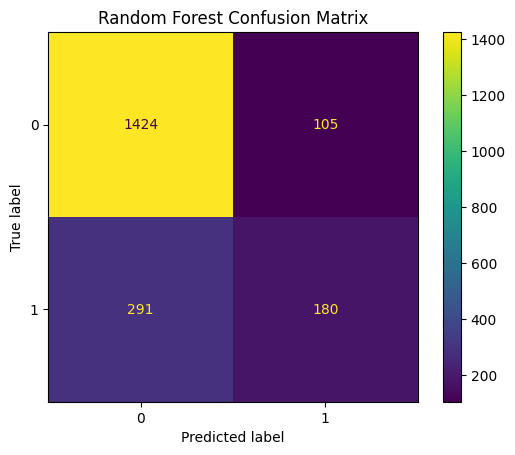

In [ ]:
# I added this chart to help really visualize the true accuracy of drop out predictions
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.title("Random Forest Confusion Matrix")
plt.show()


In [59]:
print(X_train.isnull().sum())
print(X_test.isnull().sum())

GPA                    0
Semester_GPA           0
Stress_Index         407
Family_Income        407
gpa_gap                0
high_stress            0
low_income             0
has_scholarship        0
has_part_time_job      0
dtype: int64
GPA                   0
Semester_GPA          0
Stress_Index         93
Family_Income        93
gpa_gap               0
high_stress           0
low_income            0
has_scholarship       0
has_part_time_job     0
dtype: int64


In [62]:
## 6. Model 2: [log reg]
lr = LogisticRegression(max_iter=1000, random_state=42)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.803
              precision    recall  f1-score   support

           0       0.83      0.94      0.88      1529
           1       0.65      0.35      0.46       471

    accuracy                           0.80      2000
   macro avg       0.74      0.65      0.67      2000
weighted avg       0.78      0.80      0.78      2000



In [ ]:
##Tried using GridSearchCV to test different hyperparameters for lr (i used the website you reccomended)
lr = LogisticRegression(max_iter=1000)
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['lbfgs']
}

grid_lr = GridSearchCV(
    estimator=lr,
    param_grid=param_grid_lr,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)

best_lr = grid_lr.best_estimator_

print("Best Logistic Regression Parameters:")
print(grid_lr.best_params_)

Best Logistic Regression Parameters:
{'C': 1, 'solver': 'lbfgs'}


In [63]:
## 7. Model Comparison
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Random Forest", "Logistic Regression"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_lr)
    ]
})

comparison

,Model,Accuracy
0,Random Forest,0.781
1,Logistic Regression,0.803


In [73]:
#This is my tuned model comparison once i added the GridSearchCV
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Tuned Random Forest", "Tuned Logistic Regression"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_lr)
    ]
})

comparison

,Model,Accuracy
0,Tuned Random Forest,0.802
1,Tuned Logistic Regression,0.803


Logistic regression performed better than the Random forest model very slightly. I believe that the logistic regression was able to better capture patterns between the features, because they were already pretty simple. Honestly, the same goes with the random forest. Random forest performs well with complex features however, and this data was not as complex as most, which could explain why it slightly underperformed.

#Model Selection
Based on my findings, I would choose the Logistic regression moel, because of the higher accuracy value. The values were super close though, so in the future I would most likely add more features for each system to find correlations. ALso, a lot of the data that was missing was either removed or imported as the mean, which can throw off some values.

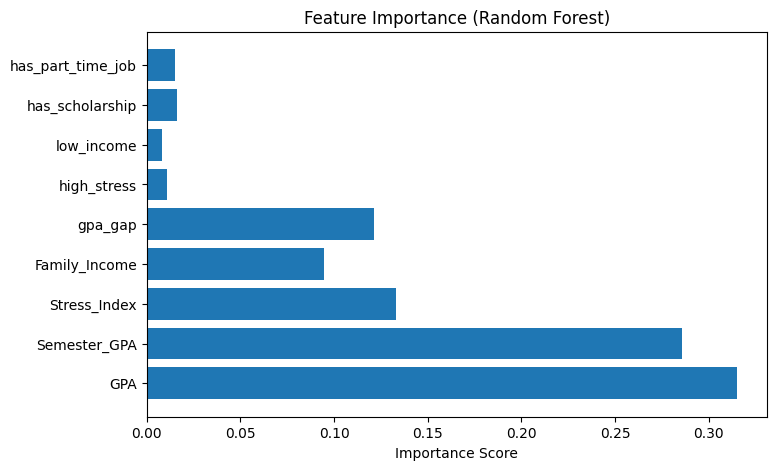

In [65]:
import matplotlib.pyplot as plt

importances = rf.feature_importances_
features = X_train.columns

plt.figure(figsize=(8,5))
plt.barh(features, importances)
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.show()

In [64]:
from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_rf).ravel()

specificity = tn / (tn + fp)
fpr = fp / (fp + tn)
fnr = fn / (fn + tp)

print("Specificity:", specificity)
print("False Positive Rate:", fpr)
print("False Negative Rate:", fnr)

Specificity: 0.8574231523871811
False Positive Rate: 0.14257684761281883
False Negative Rate: 0.46709129511677283


## 8. Next Steps & Reflection
[ When reviewing the models, i made sure to consider any bias within the data.
First i recognize that the stress levels are up for interpretation, but they are used as a baseline in my data.
Also, categories like income and part time job are a bias reflection in the data and 
really shouldn't be used to determine drop out rates as a final say.]

##Business recommendations
[
In order to keep students in school based on my findings, I would reccomend,
sharing these findings with students so they are aware of their potential risk of 
dropping out. After making students aware, schools should provide support and guidance
to help students regulate stress, difficult schedules and financial troubles.
]

#conclusion
[ In the graphs we can see that academic performance, workload and stress levels are all key 
 factors in dropout rates. As far as my income analysis, I did not see any substantial
 indicators suggesting that lower income results in a higher drop out rate.
 Academic performance, worload and stress levels were also ranked higher in the feature importance score
 relative to income level. Overall, my models also performed relatively well. The grid search 
 addition created a better accuraccy level.]